# Demand Forecasting and Inventory Optimization

In this project, we forecast future customer demand using data-driven time series models (ARIMA/SARIMA) based on historical sales data and key market factors. Guided by these demand projections, we implement inventory optimization strategies in Python to ensure seamless customer fulfillment while minimizing holding and stockout costs.

<img src='https://www.infosysbpm.com/content/dam/infosys-bpm/en/blogs/images/5-ways-ai-can-benefit-demand-forecasting-and-inventory-planning-medium.jpg' width='750'>

In [1]:
#Libraries
import pandas as pd
import numpy as np
import plotly.express as px
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

### EDA

In [2]:
df=pd.read_csv('demand_inventory.csv')

In [3]:
df.head()

,Unnamed: 0,Date,Product_ID,Demand,Inventory
0,0,2023-06-01,P1,51,5500
1,1,2023-06-02,P1,141,5449
2,2,2023-06-03,P1,172,5308
3,3,2023-06-04,P1,91,5136
4,4,2023-06-05,P1,198,5045


In [4]:
df.tail()

,Unnamed: 0,Date,Product_ID,Demand,Inventory
57,57,2023-07-28,P1,174,0
58,58,2023-07-29,P1,72,0
59,59,2023-07-30,P1,52,0
60,60,2023-07-31,P1,188,0
61,61,2023-08-01,P1,102,0


In [5]:
df.shape

(62, 5)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  62 non-null     int64 
 1   Date        62 non-null     object
 2   Product_ID  62 non-null     object
 3   Demand      62 non-null     int64 
 4   Inventory   62 non-null     int64 
dtypes: int64(3), object(2)
memory usage: 2.6+ KB


In [7]:
df.isnull().sum()

Unnamed: 0    0
Date          0
Product_ID    0
Demand        0
Inventory     0
dtype: int64

In [8]:
df.describe()

,Unnamed: 0,Demand,Inventory
count,62.000000,62.000000,62.000000
mean,30.500000,120.709677,2073.822581
std,18.041619,44.852906,1840.782144
min,0.000000,51.000000,0.000000
25%,15.250000,85.000000,25.500000
50%,30.500000,124.000000,1908.000000
75%,45.750000,152.750000,3594.250000
max,61.000000,199.000000,5500.000000


In [9]:
df.corr(numeric_only=True)

,Unnamed: 0,Demand,Inventory
Unnamed: 0,1.000000,0.013492,-0.981537
Demand,0.013492,1.000000,-0.004079
Inventory,-0.981537,-0.004079,1.000000


In [12]:
del df['Unnamed: 0']

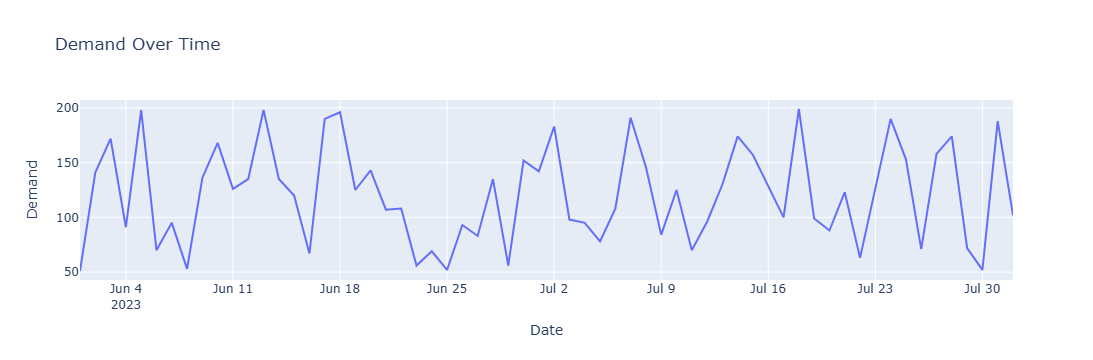

In [15]:
fig_demand = px.line(df, x='Date',
                     y='Demand',
                     title='Demand Over Time')
fig_demand.show()

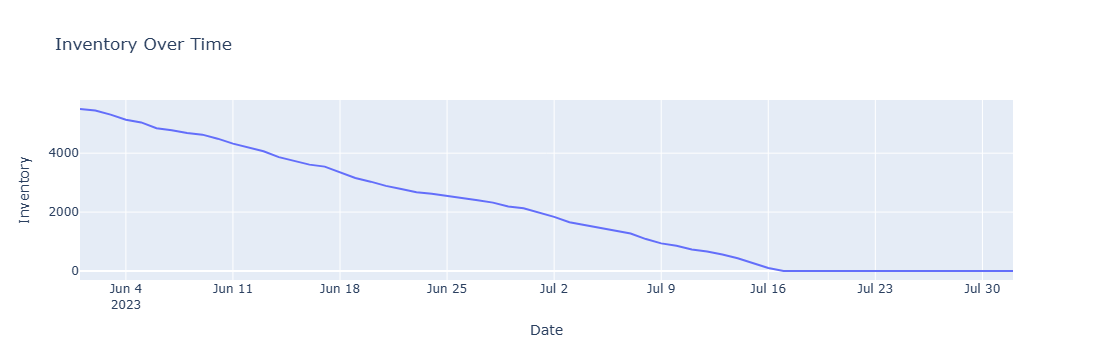

In [17]:
fig_inventory = px.line(df, x='Date',
                        y='Inventory',
                        title='Inventory Over Time')
fig_inventory.show()

#### Demand Forecasting

In [20]:
df['Date'] = pd.to_datetime(df['Date'],
                                     format='%Y-%m-%d')
time_series = df.set_index('Date')['Demand']

differenced_series = time_series.diff().dropna()


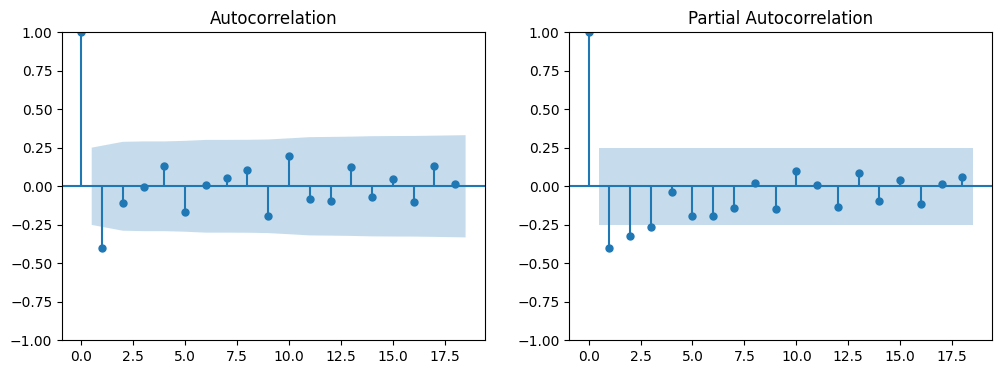

In [21]:
# Plot ACF and PACF of differenced time series
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(differenced_series, ax=axes[0])
plot_pacf(differenced_series, ax=axes[1])
plt.show()

In [22]:
order = (1, 1, 1)
seasonal_order = (1, 1, 1, 2) #2 because the data contains a time period of 2 months only
model = SARIMAX(time_series, order=order, seasonal_order=seasonal_order)
model_fit = model.fit(disp=False)

future_steps = 10
predictions = model_fit.predict(len(time_series), len(time_series) + future_steps - 1)
predictions = predictions.astype(int)
print(predictions)

2023-08-02    117
2023-08-03    116
2023-08-04    130
2023-08-05    114
2023-08-06    128
2023-08-07    115
2023-08-08    129
2023-08-09    115
2023-08-10    129
2023-08-11    115
Freq: D, Name: predicted_mean, dtype: int64


C:\Users\furka\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

C:\Users\furka\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.



### Inventory Optimization

In [24]:
future_dates = pd.date_range(time_series.index[-1] + pd.Timedelta(days=1), periods=future_steps)
forecasted_demand = pd.Series(predictions, index=future_dates)
forecasted_demand

2023-08-02    117
2023-08-03    116
2023-08-04    130
2023-08-05    114
2023-08-06    128
2023-08-07    115
2023-08-08    129
2023-08-09    115
2023-08-10    129
2023-08-11    115
Freq: D, Name: predicted_mean, dtype: int64

In [25]:
initial_inventory = 5500
lead_time = 1
service_level = 0.95
holding_cost = 0.1
stockout_cost = 10

In [27]:
z = np.abs(np.percentile(forecasted_demand, 100 * (1 - service_level)))
mean_demand = forecasted_demand.mean()
z

np.float64(114.45)

In [28]:
order_quantity = np.ceil(mean_demand + z).astype(int)
order_quantity

np.int64(236)

In [29]:
reorder_point = mean_demand * lead_time + z
reorder_point

np.float64(235.25)

In [30]:
safety_stock = reorder_point - (mean_demand * lead_time)
safety_stock

np.float64(114.45)

In [31]:
total_holding_cost = holding_cost * (initial_inventory + 0.5 * order_quantity)
total_stockout_cost = stockout_cost * max(0, mean_demand * lead_time - initial_inventory)

In [32]:
total_cost = total_holding_cost + total_stockout_cost
total_cost

np.float64(561.8000000000001)

In [33]:
pd.DataFrame({
    'Metric': ['Optimal Order Quantity', 'Reorder Point', 'Safety Stock', 'Total Cost'],
    'Value': [order_quantity, reorder_point, safety_stock, total_cost]
})

,Metric,Value
0,Optimal Order Quantity,236.00
1,Reorder Point,235.25
2,Safety Stock,114.45
3,Total Cost,561.80


In this project, we built a data-driven pipeline in Python for Demand Forecasting and Inventory Optimization.

By using time-series modeling (ARIMA/SARIMA) to predict future customer demand and applying key inventory formulas, we determined the optimal order quantity, reorder point, and safety stock. This approach allows businesses to maintain high service levels while minimizing overall holding and stockout costs.